<a href="https://colab.research.google.com/github/vitor-thompson/Python-para-financas-investimento-e-analise-de-dados./blob/main/Python_para_financas_investimento_e_analise_de_dados(Codigo_Final).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Biblioteca

In [ ]:
# Instala a biblioteca yfinance, usada para baixar dados financeiros.
!pip install -q yfinance

# Importa as bibliotecas necessárias para manipulação de dados e plotagem.
import numpy as np           # Para operações numéricas e arrays.
import pandas as pd          # Para manipulação e análise de dados (DataFrames).
import yfinance as yf        # Para baixar dados financeiros de forma fácil.
import matplotlib.pyplot as plt # Para criar gráficos e visualizações.
# Configura o matplotlib para exibir os gráficos diretamente no notebook.
%matplotlib inline

# Coleta de Dados e Cálculo de Retornos

In [ ]:
# Define os ativos para o portfólio que será otimizado usando a Fronteira Eficiente de Markowitz.
assets = ['ITUB4.SA','ITSA4.SA','TAEE11.SA','VALE3.SA','PETR4.SA', 'RADL3.SA', 'WEGE3.SA','BBSE3.SA', '^BVSP']
acoes = ['ITUB4.SA','ITSA4.SA','TAEE11.SA','VALE3.SA','PETR4.SA', 'RADL3.SA', 'WEGE3.SA','BBSE3.SA']

# Cria um DataFrame vazio para armazenar os preços de fechamento desses ativos.
pf_data = pd.DataFrame()

# Baixa os preços de fechamento históricos para cada ativo desde 1º de janeiro de 2000.
# Os dados são armazenados no DataFrame 'pf_data'.
for t in assets:
    pf_data[t] = yf.download(t, start='2000-1-1')['Close']

In [ ]:
pf_data.tail()

,ITUB4.SA,ITSA4.SA,TAEE11.SA,VALE3.SA,PETR4.SA,WEGE3.SA,BBSE3.SA,^BVSP
Date,,,,,,,,
2026-04-14,46.529999,14.83,45.400002,88.300003,47.880001,51.900002,35.730000,198657.000000
2026-04-15,47.040001,15.00,45.570000,88.440002,46.889999,49.959999,35.049999,197738.000000
2026-04-16,46.980000,14.81,44.299999,87.440002,48.580002,48.400002,35.009998,196819.000000
2026-04-17,46.799999,14.81,45.009998,89.750000,46.220001,48.650002,34.919998,195734.000000
2026-04-20,46.660000,14.87,45.549999,89.089996,47.060001,48.740002,35.160000,196328.671875


# Análise de Risco e Retorno Individual (Seleção Preliminar)

<Axes: xlabel='Date'>

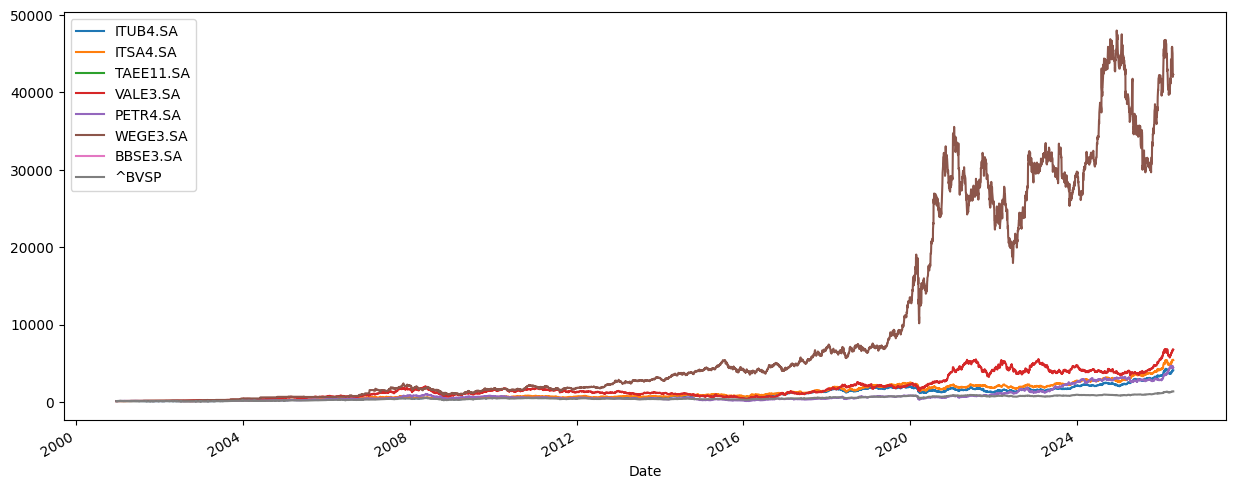

In [ ]:
(pf_data / pf_data.iloc[0] * 100).plot(figsize=(15, 6))

In [ ]:
retornos_log = np.log(pf_data / pf_data.shift(1))

In [ ]:
# Define o número de dias úteis em um ano para anualização.
dias_uteis = 250
# Calcula o retorno logarítmico anualizado médio para cada ativo.
# Este é o retorno esperado anual para cada ativo no portfólio.
retornos_log.mean() * dias_uteis

,0
ITUB4.SA,0.146104
ITSA4.SA,0.157131
TAEE11.SA,0.165500
VALE3.SA,0.165962
PETR4.SA,0.149180
WEGE3.SA,0.238209
BBSE3.SA,0.136125
^BVSP,0.096942


In [ ]:
# Calcula a volatilidade anualizada dos retornos logarítmicos dos ativos.
retornos_log.std() * np.sqrt(dias_uteis)

,0
ITUB4.SA,0.338607
ITSA4.SA,0.389724
TAEE11.SA,0.261330
VALE3.SA,0.389463
PETR4.SA,0.412270
WEGE3.SA,0.325015
BBSE3.SA,0.276214
^BVSP,0.265047


# Análise de Risco Relativo (Risco Sistemático)

In [ ]:
# Calcula a matriz de covariância anualizada dos retornos logarítmicos dos ativos.
# A covariância mede como os retornos dos ativos se movem em relação uns aos outros.
retornos_log.cov() * dias_uteis

,ITUB4.SA,ITSA4.SA,TAEE11.SA,VALE3.SA,PETR4.SA,WEGE3.SA,BBSE3.SA,^BVSP
ITUB4.SA,0.114655,0.094917,0.024682,0.054410,0.070716,0.030152,0.044440,0.069044
ITSA4.SA,0.094917,0.151885,0.023992,0.050338,0.068755,0.031479,0.043026,0.065043
TAEE11.SA,0.024682,0.023992,0.068293,0.018361,0.026984,0.016482,0.019723,0.023041
VALE3.SA,0.054410,0.050338,0.018361,0.151681,0.075517,0.029092,0.025899,0.065074
PETR4.SA,0.070716,0.068755,0.026984,0.075517,0.169967,0.032261,0.049232,0.077521
WEGE3.SA,0.030152,0.031479,0.016482,0.029092,0.032261,0.105635,0.027139,0.032075
BBSE3.SA,0.044440,0.043026,0.019723,0.025899,0.049232,0.027139,0.076294,0.037496
^BVSP,0.069044,0.065043,0.023041,0.065074,0.077521,0.032075,0.037496,0.070250


In [ ]:
# Calcula a matriz de covariância anualizada dos retornos logarítmicos.
# A covariância mede como os retornos de dois ativos se movem em conjunto (se sobem e descem juntos).
# Multiplicar por 'dias_uteis' anualiza a covariância diária.
cov = retornos_log.cov() * dias_uteis

# Exibe a matriz de covariância anualizada.
cov

,ITUB4.SA,ITSA4.SA,TAEE11.SA,VALE3.SA,PETR4.SA,WEGE3.SA,BBSE3.SA,^BVSP
ITUB4.SA,0.114655,0.094917,0.024682,0.054410,0.070716,0.030152,0.044440,0.069044
ITSA4.SA,0.094917,0.151885,0.023992,0.050338,0.068755,0.031479,0.043026,0.065043
TAEE11.SA,0.024682,0.023992,0.068293,0.018361,0.026984,0.016482,0.019723,0.023041
VALE3.SA,0.054410,0.050338,0.018361,0.151681,0.075517,0.029092,0.025899,0.065074
PETR4.SA,0.070716,0.068755,0.026984,0.075517,0.169967,0.032261,0.049232,0.077521
WEGE3.SA,0.030152,0.031479,0.016482,0.029092,0.032261,0.105635,0.027139,0.032075
BBSE3.SA,0.044440,0.043026,0.019723,0.025899,0.049232,0.027139,0.076294,0.037496
^BVSP,0.069044,0.065043,0.023041,0.065074,0.077521,0.032075,0.037496,0.070250


In [ ]:
# Calcula a matriz de correlação dos retornos logarítmicos dos ativos.
# A correlação é uma medida padronizada da covariância, indicando a força e direção da relação linear entre os retornos.
correlations = retornos_log.corr()

# Exibe a matriz de correlação anualizada.
correlations

,ITUB4.SA,ITSA4.SA,TAEE11.SA,VALE3.SA,PETR4.SA,WEGE3.SA,BBSE3.SA,^BVSP
ITUB4.SA,1.000000,0.719264,0.280784,0.412586,0.506573,0.273976,0.531210,0.765985
ITSA4.SA,0.719264,1.000000,0.270788,0.331642,0.427923,0.248519,0.551177,0.625811
TAEE11.SA,0.280784,0.270788,1.000000,0.170992,0.233314,0.189901,0.319692,0.337814
VALE3.SA,0.412586,0.331642,0.170992,1.000000,0.470326,0.229831,0.231930,0.626663
PETR4.SA,0.506573,0.427923,0.233314,0.470326,1.000000,0.240767,0.388084,0.704764
WEGE3.SA,0.273976,0.248519,0.189901,0.229831,0.240767,1.000000,0.310222,0.370163
BBSE3.SA,0.531210,0.551177,0.319692,0.231930,0.388084,0.310222,1.000000,0.579660
^BVSP,0.765985,0.625811,0.337814,0.626663,0.704764,0.370163,0.579660,1.000000


In [ ]:
# Extrai da matriz de covariância (cov) as covariâncias de cada ação com o Ibovespa ('^BVSP').
# 'tikers[:-1]' seleciona todos os tickers exceto o último (que é o '^BVSP'),
# e '^BVSP' seleciona a coluna correspondente ao Ibovespa.
cov_acoes_com_ibovespa = cov.loc[assets[:-1], '^BVSP']


# Exibe as covariâncias das ações com o Ibovespa.
display(cov_acoes_com_ibovespa)

,^BVSP
ITUB4.SA,0.069044
ITSA4.SA,0.065043
TAEE11.SA,0.023041
VALE3.SA,0.065074
PETR4.SA,0.077521
WEGE3.SA,0.032075
BBSE3.SA,0.037496


In [ ]:
# Itera sobre cada ação e sua respectiva covariância com o Ibovespa.
# Imprime o valor da covariância formatado para 6 casas decimais e o tipo de dado para verificação.
for stock, covariance_value in cov_acoes_com_ibovespa.items():
    print(f"A covariância de {stock} com o Ibovespa é: {covariance_value:.6f} (Tipo: {type(covariance_value)})")

A covariância de ITUB4.SA com o Ibovespa é: 0.069044 (Tipo: <class 'float'>)
A covariância de ITSA4.SA com o Ibovespa é: 0.065043 (Tipo: <class 'float'>)
A covariância de TAEE11.SA com o Ibovespa é: 0.023041 (Tipo: <class 'float'>)
A covariância de VALE3.SA com o Ibovespa é: 0.065074 (Tipo: <class 'float'>)
A covariância de PETR4.SA com o Ibovespa é: 0.077521 (Tipo: <class 'float'>)
A covariância de WEGE3.SA com o Ibovespa é: 0.032075 (Tipo: <class 'float'>)
A covariância de BBSE3.SA com o Ibovespa é: 0.037496 (Tipo: <class 'float'>)


In [ ]:
# Calcula a variância anualizada dos retornos do mercado (Ibovespa, '^BVSP').
# A variância do mercado é um componente crucial para o cálculo do Beta, pois mede a volatilidade do mercado.
# Multiplicar por 'dias_uteis' anualiza a variância diária.
market_var = retornos_log['^BVSP'].var() * dias_uteis

# Exibe a variância anualizada do mercado.
market_var

0.07024982199771064

In [ ]:
# Calcula o Beta para cada ação.
# O Beta é uma medida de risco sistemático, indicando a sensibilidade do retorno de uma ação
# em relação ao retorno do mercado (Ibovespa).
# É calculado como a covariância da ação com o mercado dividida pela variância do mercado.
beta_stocks = cov_acoes_com_ibovespa / market_var

# Exibe os valores de Beta para cada ação.
display(beta_stocks)

,^BVSP
ITUB4.SA,0.982833
ITSA4.SA,0.925877
TAEE11.SA,0.327984
VALE3.SA,0.926324
PETR4.SA,1.103499
WEGE3.SA,0.456585
BBSE3.SA,0.533748


# Otimização do Portfólio (Teoria de Markowitz)

In [ ]:
# Obtém o número de ativos no portfólio.
num_assets = len(assets)
num_acoes = len(acoes)
#num_acoes_1 = len(acoes_1)

In [ ]:
retorno_log_acoes = np.log(pf_data / pf_data.shift(1))[acoes]
retorno_log_acoes

,ITUB4.SA,ITSA4.SA,TAEE11.SA,VALE3.SA,PETR4.SA,WEGE3.SA,BBSE3.SA
Date,,,,,,,
2000-12-21,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-12-22,-0.044312,-0.010810,NaN,0.022990,0.006689,0.000000,NaN
2000-12-25,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,NaN
2000-12-26,-0.000291,0.010810,NaN,0.000000,-0.006689,0.000000,NaN
2000-12-27,0.033355,0.005362,NaN,0.044452,0.013333,0.000000,NaN
...,...,...,...,...,...,...,...
2026-04-14,0.015158,0.008125,0.005300,0.010703,-0.038915,-0.002694,-0.008916
2026-04-15,0.010901,0.011398,0.003737,0.001584,-0.020893,-0.038096,-0.019215
2026-04-16,-0.001276,-0.012748,-0.028265,-0.011372,0.035408,-0.031723,-0.001142


In [ ]:
# Inicializa listas para armazenar os retornos e volatilidades dos portfólios simulados, e os pesos dos ativos.
pfolio_returne = []
pfolio_volatility = []
pfolio_weights = []

# Loop para gerar um grande número de portfólios aleatórios.
for x in range(10000):
    # Gera pesos aleatórios para os ativos no portfólio.
    weights = np.random.random(num_acoes)
    # Normaliza os pesos para que a soma seja igual a 1.
    weights /= np.sum(weights)
    # Adiciona os pesos à lista.
    pfolio_weights.append(weights)
    # Calcula o retorno anualizado do portfólio e adiciona à lista.
    pfolio_returne.append(np.sum(weights * retorno_log_acoes.mean()) * dias_uteis)
    # Calcula a volatilidade anualizada do portfólio e adiciona à lista.
    pfolio_volatility.append(np.sqrt(np.dot(weights.T, np.dot(retorno_log_acoes.cov() * dias_uteis, weights))))

# Converte as listas para arrays numpy para facilitar operações futuras.
pfolio_returne = np.array(pfolio_returne)
pfolio_volatility = np.array(pfolio_volatility)
pfolio_weights = np.array(pfolio_weights)

# Exibe os arrays de retorno e volatilidade gerados.
pfolio_returne, pfolio_volatility, pfolio_weights

(array([0.1730095 , 0.15405944, 0.16080729, ..., 0.16459659, 0.15503621,
        0.16555269]),
 array([0.21442729, 0.23353625, 0.23518878, ..., 0.23607352, 0.25912401,
        0.23556622]),
 array([[0.01582946, 0.12628586, 0.19791311, ..., 0.15932268, 0.25067998,
         0.23019734],
        [0.22275929, 0.1038643 , 0.18042652, ..., 0.18114693, 0.0464366 ,
         0.22767308],
        [0.14658286, 0.2404158 , 0.25224536, ..., 0.16537521, 0.0834234 ,
         0.10911868],
        ...,
        [0.17579851, 0.07927807, 0.04551439, ..., 0.17902168, 0.17017897,
         0.21596184],
        [0.08651295, 0.26566275, 0.0437102 , ..., 0.19991874, 0.03365964,
         0.19834907],
        [0.32142306, 0.06128526, 0.12272109, ..., 0.05242491, 0.14109161,
         0.09189936]]))

In [ ]:
# Cria um DataFrame pandas para organizar os retornos e volatilidades dos portfólios simulados.
# Este DataFrame será usado para visualizar a fronteira eficiente.
portifolios = pd.DataFrame({'Return': pfolio_returne, 'Volatility': pfolio_volatility, 'Weights': list(pfolio_weights)})

In [ ]:
# Exibe as primeiras linhas do DataFrame 'portifolios'.
# Isso permite uma visualização rápida da estrutura dos dados dos portfólios gerados.
portifolios.head()

,Return,Volatility,Weights
0,0.173010,0.214427,"[0.015829457676146776, 0.126285858212074, 0.19..."
1,0.154059,0.233536,"[0.2227592874300365, 0.10386429785063368, 0.18..."
2,0.160807,0.235189,"[0.14658285988814665, 0.24041579568081922, 0.2..."
3,0.173151,0.226952,"[0.14445046953325344, 0.10688716477497916, 0.1..."
4,0.157518,0.270059,"[0.19188454297703336, 0.30999274545378325, 0.1..."


In [ ]:
# Exibe as últimas linhas do DataFrame 'portifolios'.
# Isso ajuda a verificar a completude e a faixa dos dados simulados.
portifolios.tail()

,Return,Volatility,Weights
9995,0.175116,0.239838,"[0.009429490137065054, 0.18929804259438143, 0...."
9996,0.170130,0.242127,"[0.1731581081746167, 0.20662551906379903, 0.02..."
9997,0.164597,0.236074,"[0.175798513300926, 0.0792780673325473, 0.0455..."
9998,0.155036,0.259124,"[0.08651295323534337, 0.2656627463252862, 0.04..."
9999,0.165553,0.235566,"[0.3214230591190537, 0.06128526359400235, 0.12..."


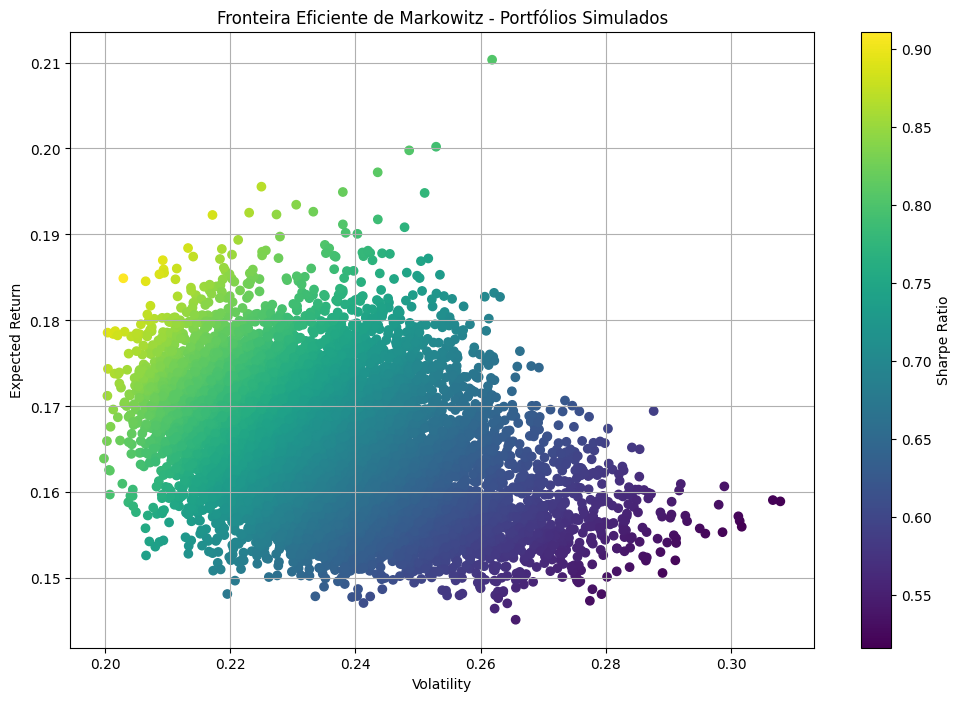

In [ ]:
# Plota os portfólios simulados, com a volatilidade no eixo X e o retorno esperado no eixo Y.
# Este gráfico de dispersão é fundamental para visualizar a Fronteira Eficiente de Markowitz.
plt.figure(figsize=(12, 8))
plt.scatter(x=portifolios['Volatility'], y=portifolios['Return'], c=(portifolios['Return'] / portifolios['Volatility']), cmap='viridis')
plt.xlabel('Volatility')
plt.ylabel('Expected Return')
plt.title('Fronteira Eficiente de Markowitz - Portfólios Simulados')
plt.colorbar(label='Sharpe Ratio')
plt.grid(True)
plt.show()

In [ ]:
# Encontra o portfólio com o maior Sharpe Ratio.
taxa_risco_livre = 0.15
sharpe_ratio = (portifolios['Return'] - taxa_risco_livre) / portifolios['Volatility']
optimal_portfolio = portifolios.loc[sharpe_ratio.idxmax()]

# Exibe os pesos dos ativos para o portfólio ótimo.
print("Pesos do Portfólio Ótimo (Maior Sharpe Ratio):")
for asset, weight in zip(assets, optimal_portfolio['Weights']):
    print(f"  {asset}: {weight:.4f}")

print(f"\nRetorno Esperado: {optimal_portfolio['Return']:.4f}")
print(f"Volatilidade: {optimal_portfolio['Volatility']:.4f}")

Pesos do Portfólio Ótimo (Maior Sharpe Ratio):
  ITUB4.SA: 0.0062
  ITSA4.SA: 0.0615
  TAEE11.SA: 0.0088
  VALE3.SA: 0.1860
  PETR4.SA: 0.0505
  WEGE3.SA: 0.6502
  BBSE3.SA: 0.0368

Retorno Esperado: 0.2103
Volatilidade: 0.2618


# Verificação e validação (Simulação de Monte Carlo)

In [ ]:
# Calcula os retornos logarítmicos diários para cada ativo no DataFrame 'pf_data'.
# pct_change() calcula a variação percentual entre o período atual e o anterior.
# np.log(1 + variação_percentual) é a fórmula para o retorno logarítmico.
retorno_log = np.log(1 + pf_data.pct_change())

/tmp/ipykernel_6895/2325674656.py:4: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  retorno_log = np.log(1 + pf_data.pct_change())


In [ ]:
# Calcula a média dos retornos logarítmicos diários para cada ativo.
# Esta é a base para o 'drift' (tendência de crescimento) na simulação de Monte Carlo.
media_retorno_diario = retorno_log.mean()

In [ ]:
# Calcula a matriz de covariância dos retornos logarítmicos diários.
# A covariância é usada para determinar a volatilidade do portfólio na simulação.
covariancia_ano = retorno_log.cov()

In [ ]:
# Calcula o valor inicial do portfólio (S0_portfolio).
# É a soma do produto do preço de fechamento mais recente de cada ativo (pf_data.iloc[-1])
# pelos pesos ótimos calculados anteriormente (weights).
S0_portfolio = np.sum(pf_data.iloc[-1][acoes] * weights)
S0_portfolio

np.float64(52.70755311242197)

In [ ]:
from scipy.stats import norm

media_retorno_diario = retorno_log_acoes.mean()
covariancia_ano = retorno_log_acoes.cov()
S0_portfolio = np.sum(pf_data.iloc[-1][acoes] * weights*100)

# Define os parâmetros da simulação
t_intervalos = 252  # Número de dias úteis em um ano
#t_intervalos = 21
interacoes = 10000   # Número de caminhos de simulação (cenários)

# Obtém os pesos ótimos do portfólio calculados na otimização da Fronteira Eficiente.
optimal_weights = optimal_portfolio['Weights']

# Calcula o 'drift' diário do portfólio ótimo.
# O drift é a média dos retornos ponderada pelos pesos ótimos.
port_drift_daily = np.sum(optimal_weights * media_retorno_diario)

# Calcula a volatilidade diária do portfólio ótimo.
# Usa a matriz de covariância dos retornos e os pesos ótimos.
port_volatility = np.sqrt(np.dot(optimal_weights.T, np.dot(covariancia_ano, optimal_weights)))

# Gera os retornos acumulados do portfólio para a simulação de Monte Carlo.
# Utiliza a fórmula de movimento browniano geométrico para simular os retornos futuros.
retorno_acumulado_portfolio = np.exp(port_drift_daily + port_volatility * norm.ppf(np.random.rand(t_intervalos, interacoes)))

In [ ]:
# Inicializa uma matriz de zeros para armazenar os preços simulados do portfólio.
# Ela terá as mesmas dimensões que 'retorno_acumulado_portfolio'.
lista_precos_portfolio = np.zeros_like(retorno_acumulado_portfolio)

In [ ]:
# Define o primeiro dia de cada caminho simulado com o valor inicial do portfólio.
# S0_portfolio é o valor atual do portfólio.
lista_precos_portfolio[0] = S0_portfolio

In [ ]:
# Loop para calcular os preços do portfólio ao longo do tempo para cada caminho simulado.
# Cada preço futuro é calculado multiplicando o preço do dia anterior pelo retorno acumulado do dia atual.
for t in range(1, t_intervalos):
    lista_precos_portfolio[t] = lista_precos_portfolio[t - 1] * retorno_acumulado_portfolio[t]

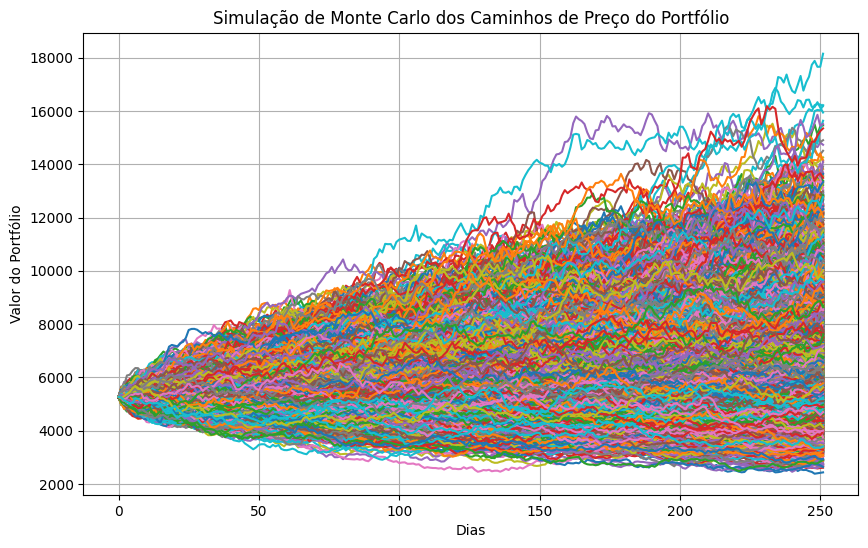

In [ ]:
# Cria um gráfico de linhas para visualizar os caminhos de preço simulados do portfólio.
plt.figure(figsize=(10, 6))
plt.plot(lista_precos_portfolio)
plt.title('Simulação de Monte Carlo dos Caminhos de Preço do Portfólio')
plt.xlabel('Dias')
plt.ylabel('Valor do Portfólio')
plt.grid(True)
plt.show()

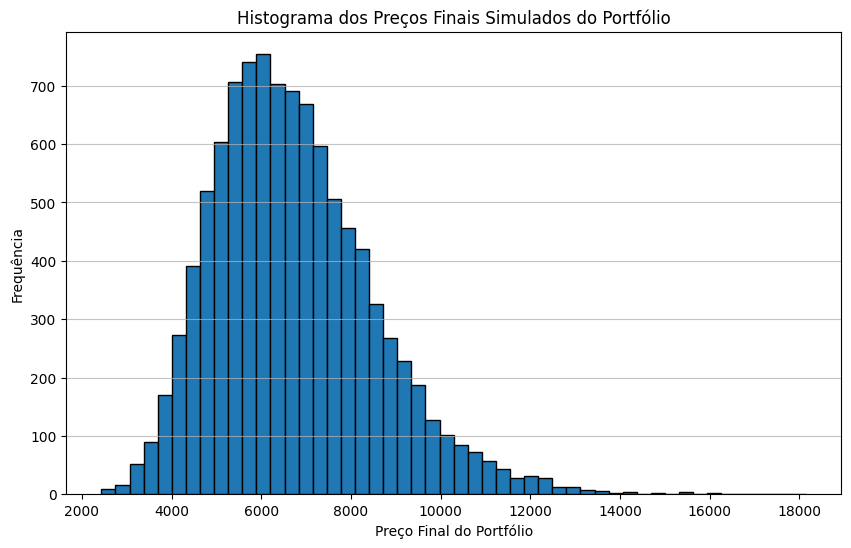

In [ ]:
# Cria uma nova figura para o histograma.
plt.figure(figsize=(10, 6))

# Plota o histograma dos preços finais simulados.
# Usamos lista_precos_portfolio[-1] para obter a última linha, que corresponde aos preços finais de cada simulação.
# O argumento 'bins' define o número de barras do histograma.
plt.hist(lista_precos_portfolio[-1], bins=50, edgecolor='black')

plt.title('Histograma dos Preços Finais Simulados do Portfólio')
plt.xlabel('Preço Final do Portfólio')
plt.ylabel('Frequência')
plt.grid(axis='y', alpha=0.75)
plt.show()

# Calculando a Probabilidade de Atingir ou Superar um Valor Alvo

In [ ]:
# Defina o valor alvo (exemplo: 110% do valor inicial do portfólio)
valor_alvo = S0_portfolio * 1.12 # Substitua '1.10' pelo seu multiplicador de alvo, ou por um valor absoluto

# Obtém todos os valores finais simulados do portfólio
valores_finais_simulados = lista_precos_portfolio[-1]

# Calcula o número de simulações onde o portfólio atingiu ou superou o valor alvo
num_simulacoes_acima_alvo = np.sum(valores_finais_simulados >= valor_alvo)

# Calcula a probabilidade
prob_acima_alvo = num_simulacoes_acima_alvo / interacoes

print(f"Valor inicial do portfólio: {S0_portfolio:.2f}")
print(f"Valor alvo definido: {valor_alvo:.2f}")
print(f"Número de simulações: {interacoes}")
print(f"Número de simulações que atingiram/superaram o alvo: {num_simulacoes_acima_alvo}")
print(f"Probabilidade de o portfólio atingir ou superar {valor_alvo:.2f} em um ano: {prob_acima_alvo:.2%}")

Valor inicial do portfólio: 5270.76
Valor alvo definido: 5903.25
Número de simulações: 10000
Número de simulações que atingiram/superaram o alvo: 6405
Probabilidade de o portfólio atingir ou superar 5903.25 em um ano: 64.05%


# Calculando a Probabilidade de Ficar Abaixo de um Valor Alvo (ou Perder Valor)

In [ ]:
# Para calcular a probabilidade de ficar abaixo do valor alvo, ou especificamente abaixo do valor inicial:

# Exemplo: Probabilidade de o portfólio terminar abaixo do valor inicial
num_simulacoes_abaixo_inicial = np.sum(valores_finais_simulados < S0_portfolio)
prob_abaixo_inicial = num_simulacoes_abaixo_inicial / interacoes

print(f"Probabilidade de o portfólio terminar abaixo do valor inicial ({S0_portfolio:.2f}) em um ano: {prob_abaixo_inicial:.2%}")

# Ou, a probabilidade de não atingir o valor alvo que você definiu anteriormente
prob_abaixo_alvo = 1 - prob_acima_alvo
print(f"Probabilidade de o portfólio NÃO atingir ou superar {valor_alvo:.2f} em um ano: {prob_abaixo_alvo:.2%}")

Probabilidade de o portfólio terminar abaixo do valor inicial (5270.76) em um ano: 21.33%
Probabilidade de o portfólio NÃO atingir ou superar 5903.25 em um ano: 35.95%
